# Logistic Regression
> Perceptron Trick

In [80]:
import numpy as np
from sklearn.datasets import make_classification
x,y = make_classification(n_samples = 160, 
                         n_features=2, 
                         n_informative=2, 
                         n_redundant=0, 
                         n_classes=2, 
                         n_clusters_per_class=1,
                         class_sep=10, 
                         random_state=41, 
                         hypercube=False)

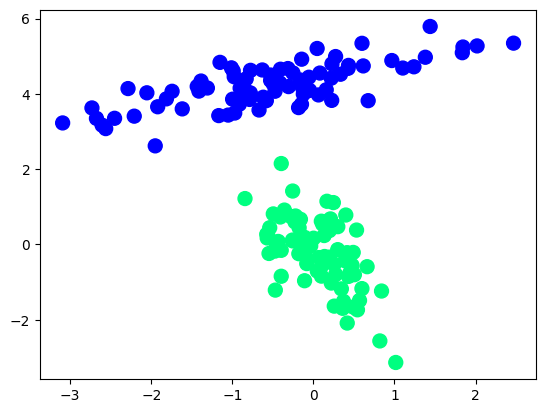

In [81]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0], x[:,1], c = y, cmap='winter', s = 100)

In [82]:
x[:5]

array([[-1.81333479,  3.86786707],
       [ 0.12799214,  0.60744422],
       [ 0.21963874,  4.41676101],
       [-0.22768011,  0.60122836],
       [-0.57532094,  0.27149769]])

In [83]:
def step(z):
    if z > 0:
        return 1
    else:
        return 0

In [84]:
def perceptron(x,y):
    x = np.insert(x,0,1,axis = 1)
    weights = np.ones(x.shape[1]) # A,B,C OR W0,W1,W2
    lr = 0.1

    for i in range(1000):
        # random point selection
        j = np.random.randint(0,x.shape[0])
        y_pred = step(np.dot(x[j], weights))
        weights += (lr * (y[j] - y_pred) * x[j])

    intercept = weights[0]
    coef = weights[1:]
    print('Intercept: ',intercept)
    print('Coef: ',coef)

In [85]:
test_run = perceptron(x,y)

Intercept:  1.4000000000000004
Coef:  [ 0.33554208 -0.57128725]


In [86]:
wo_c = 1.4000000000000004
w1_a = 0.33554208
w2_b = -0.57128725

m = -(w1_a) / (w2_b)
b = -(wo_c) / (w2_b)

print(m)
print(b)

0.5873438974876474
2.4506060655125776


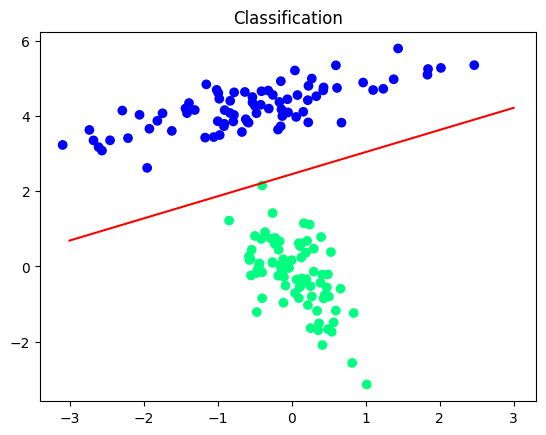

In [88]:
x_input = np.linspace(-3,3, 160)
y_input = m * x_input + b

plt.scatter(x[:,0], x[:,1], c = y, cmap='winter')
plt.plot(x_input, y_input, color = 'red')
plt.title('Classification')
plt.show()

# Logistic Regression
> sklearn

In [89]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x,y)

LogisticRegression()

In [91]:
print('A, B')
print(log.coef_)
print('C')
print(log.intercept_)

A, B
[[ 0.64422348 -2.44936993]]
C
[5.83944346]


In [95]:
m_log = -(log.coef_[0][0]) / log.coef_[0][1]
m_log

np.float64(0.263016000366915)

In [96]:
b_log = -(log.intercept_) / log.coef_[0][1]
b_log

array([2.38405942])

In [97]:
x_ip = np.linspace(-3,3, 160)
y_ip = m_log*x_ip + b_log

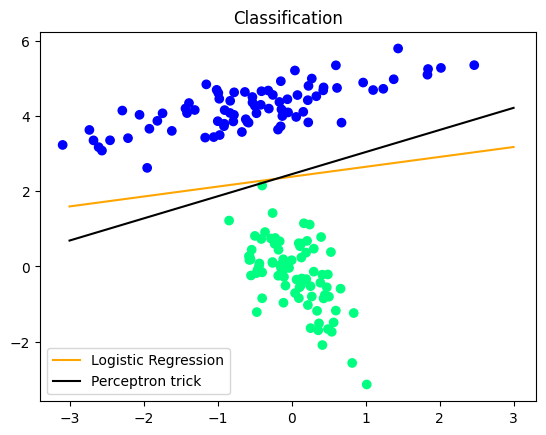

In [100]:
plt.scatter(x[:,0], x[:,1], c = y, cmap='winter')
plt.plot(x_ip, y_ip, color = 'orange', label = 'Logistic Regression')
plt.plot(x_input, y_input, color = 'k', label = 'Perceptron trick')
plt.legend()
plt.title('Classification')
plt.show()